In [9]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual formatting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

print("✓ Environment configured successfully.")

✓ Environment configured successfully.


In [10]:
# ==========================================
# 1. USER CONFIGURATION PANEL
# ==========================================
TARGET_CSV = "metrics n4,8,16,32 1e-4 gidney.csv"  # File inside saved_metrics or workspace root
WORKSPACE_DIR = Path.home() / "bicycle-architecture-compiler" / "saved_metrics"

# Select single target configuration to analyze
SELECTED_FAMILY = "brent_kung"   # Options: 'brent_kung', 'han_carlson', 'ladner_fischer', 'sklansky', 'kogge_stone'
SELECTED_N_BITS = 8              # Options: 4, 8, 16, 32

# ==========================================
# 2. INGESTION AND NORMALIZATION
# ==========================================
csv_path = WORKSPACE_DIR / TARGET_CSV if (WORKSPACE_DIR / TARGET_CSV).exists() else Path.home() / "bicycle-architecture-compiler" / TARGET_CSV
if not csv_path.exists():
    csv_path = Path(TARGET_CSV)
if not csv_path.exists():
    raise FileNotFoundError(f"Could not locate {TARGET_CSV} in {WORKSPACE_DIR} or current directory.")

df_raw = pd.read_csv(csv_path)

def parse_adder_string(name):
    m = re.match(r"([a-z_]+)_n(\d+)", str(name))
    if m:
        return m.group(1), int(m.group(2))
    return str(name), 0

df_raw[["family", "n_bits"]] = df_raw["adder"].apply(lambda x: pd.Series(parse_adder_string(x)))

# Ensure numeric columns are strictly cast
potential_numerics = [
    "measurement_depth", "end_time", "total_error", "failure_prob",
    "automorphisms", "measurements", "allocated_qubits", "pbc_steps",
    "im_gates", "im_hops", "factory_im_hops", "factory_delivery_hops",
    "total_im_events", "total_im_hops"
]
for col in potential_numerics:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Harmonize factory hop naming
if "factory_delivery_hops" in df_raw.columns and "factory_im_hops" not in df_raw.columns:
    df_raw["factory_im_hops"] = df_raw["factory_delivery_hops"]

# Filter strictly to the chosen configuration
target_tag = f"{SELECTED_FAMILY}_n{SELECTED_N_BITS}"
df_target = df_raw[(df_raw["family"] == SELECTED_FAMILY) & (df_raw["n_bits"] == SELECTED_N_BITS)].copy()

if df_target.empty:
    raise ValueError(f"No records found for configuration '{target_tag}'. Available: {df_raw['adder'].unique().tolist()}")

print(f"✓ Successfully loaded {len(df_target)} partition schemes for target configuration: {target_tag}")

✓ Successfully loaded 5 partition schemes for target configuration: brent_kung_n8


In [11]:
# Locate baseline
orig_subset = df_target[df_target["partition"] == "original"]
if orig_subset.empty:
    raise ValueError(f"Baseline partition 'original' is missing for {target_tag}. Cannot compute deltas.")
orig_row = orig_subset.iloc[0]

# Delta calculation mapping: (raw_metric_col, diff_alias, pct_alias)
target_delta_mappings = [
    ("end_time", "time_diff", "time_pct"),
    ("measurement_depth", "depth_diff", "depth_pct"),
    ("measurements", "measurements_diff", "measurements_pct"),
    ("automorphisms", "automorphisms_diff", "automorphisms_pct"),
    ("im_gates", "im_gates_diff", "im_gates_pct"),
    ("im_hops", "im_hops_diff", "im_hops_pct"),
    ("factory_im_hops", "factory_im_hops_diff", "factory_im_hops_pct"),
    ("total_im_hops", "total_im_hops_diff", "total_im_hops_pct"),
    ("total_error", "total_error_diff", "total_error_pct"),
]

augmented_rows = []
for _, row in df_target.iterrows():
    d = row.to_dict()
    for col, diff_name, pct_name in target_delta_mappings:
        if col in row and pd.notna(row[col]) and col in orig_row and pd.notna(orig_row[col]):
            diff_val = row[col] - orig_row[col]
            pct_val = ((row[col] - orig_row[col]) / orig_row[col]) * 100.0 if orig_row[col] != 0 else 0.0
            # Populate both short aliases and standardized raw names
            d[diff_name] = diff_val
            d[pct_name] = pct_val
            d[f"{col}_diff"] = diff_val
            d[f"{col}_pct"] = pct_val
    
    cap = 11 if ("allocated_qubits" in row and row["allocated_qubits"] % 11 == 0) else 12
    d["modules"] = row["allocated_qubits"] // cap if "allocated_qubits" in row else np.nan
    augmented_rows.append(d)

df_eval = pd.DataFrame(augmented_rows)

# Partition ordering and color palette setup
preferred_order = ["original", "weighted_degree", "metis", "kahypar", "clustering"]
active_schemes = [s for s in preferred_order if s in df_eval["partition"].unique()]
for s in df_eval["partition"].unique():
    if s not in active_schemes:
        active_schemes.append(s)

color_palette = dict(zip(active_schemes, sns.color_palette("tab10", len(active_schemes))))
if "original" in color_palette:
    color_palette["original"] = "#333333"

# Preferred columns in executive summary order
candidate_cols = [
    "partition", "allocated_qubits", "measurement_depth", "depth_diff", "depth_pct",
    "end_time", "time_diff", "time_pct", "automorphisms", "measurements",
    "im_gates", "im_hops", "factory_im_hops", "total_error"
]
# Keep only columns that are actually present in df_eval
display_cols = [c for c in candidate_cols if c in df_eval.columns]

print(f"\n================ Executive Scorecard: {target_tag.upper()} ================")
display(df_eval[display_cols].sort_values(by="end_time"))


================ Executive Scorecard: BRENT_KUNG_N8 ================


,partition,allocated_qubits,measurement_depth,depth_diff,depth_pct,end_time,time_diff,time_pct,automorphisms,measurements,im_gates,im_hops,factory_im_hops,total_error
2,metis,33,1333,-10,-0.744602,309864,-2256,-0.722799,12,10,13,24,43,2.981600e-16
3,kahypar,33,1335,-8,-0.595681,310200,-1920,-0.615148,6,11,11,12,25,2.981800e-16
1,weighted_degree,33,1336,-7,-0.521221,310416,-1704,-0.545944,6,11,11,16,31,2.981900e-16
4,clustering,33,1342,-1,-0.074460,311904,-216,-0.069204,12,10,19,36,24,2.982500e-16
0,original,33,1343,0,0.000000,312120,0,0.000000,12,10,48,56,57,2.982600e-16


/tmp/ipykernel_97252/3277303970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_97252/3277303970.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


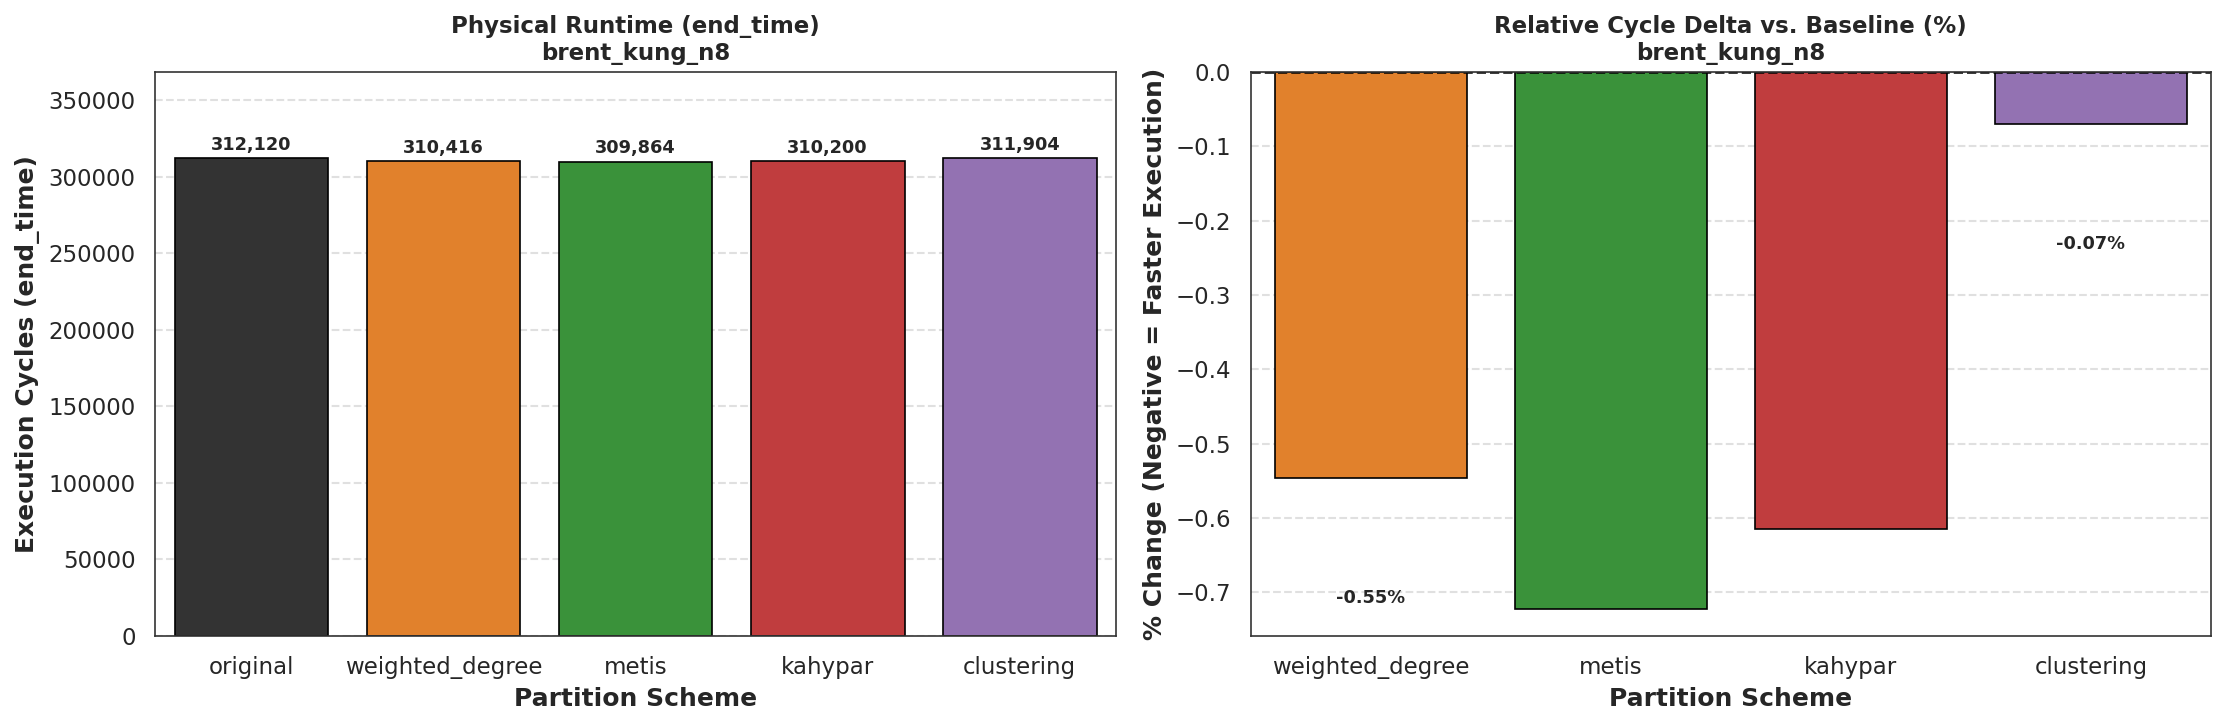

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Physical Runtime (end_time)
sns.barplot(
    data=df_eval,
    x="partition",
    y="end_time",
    order=active_schemes,
    palette=color_palette,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[0]
)

for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        axes[0].annotate(
            f"{int(h):,}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold",
            xytext=(0, 2), textcoords="offset points"
        )

axes[0].set_title(f"Physical Runtime (end_time)\n{target_tag}", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Execution Cycles (end_time)", fontweight="bold")
axes[0].set_xlabel("Partition Scheme", fontweight="bold")
axes[0].set_ylim(0, df_eval["end_time"].max() * 1.18)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# 2. Percentage Runtime Delta vs. Original Baseline
non_baseline = df_eval[df_eval["partition"] != "original"].copy()
non_base_schemes = [s for s in active_schemes if s != "original"]

sns.barplot(
    data=non_baseline,
    x="partition",
    y="time_pct",
    order=non_base_schemes,
    palette=color_palette,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)

for p in axes[1].patches:
    h = p.get_height()
    if not np.isnan(h):
        va = "bottom" if h >= 0 else "top"
        y_offset = 0.05 if h >= 0 else -0.15
        axes[1].annotate(
            f"{h:+.2f}%",
            (p.get_x() + p.get_width() / 2.0, h + y_offset),
            ha="center", va=va,
            fontsize=8.5, fontweight="bold"
        )

axes[1].set_title(f"Relative Cycle Delta vs. Baseline (%)\n{target_tag}", fontsize=11, fontweight="bold")
axes[1].set_ylabel("% Change (Negative = Faster Execution)", fontweight="bold")
axes[1].set_xlabel("Partition Scheme", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_97252/1532661785.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_97252/1532661785.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


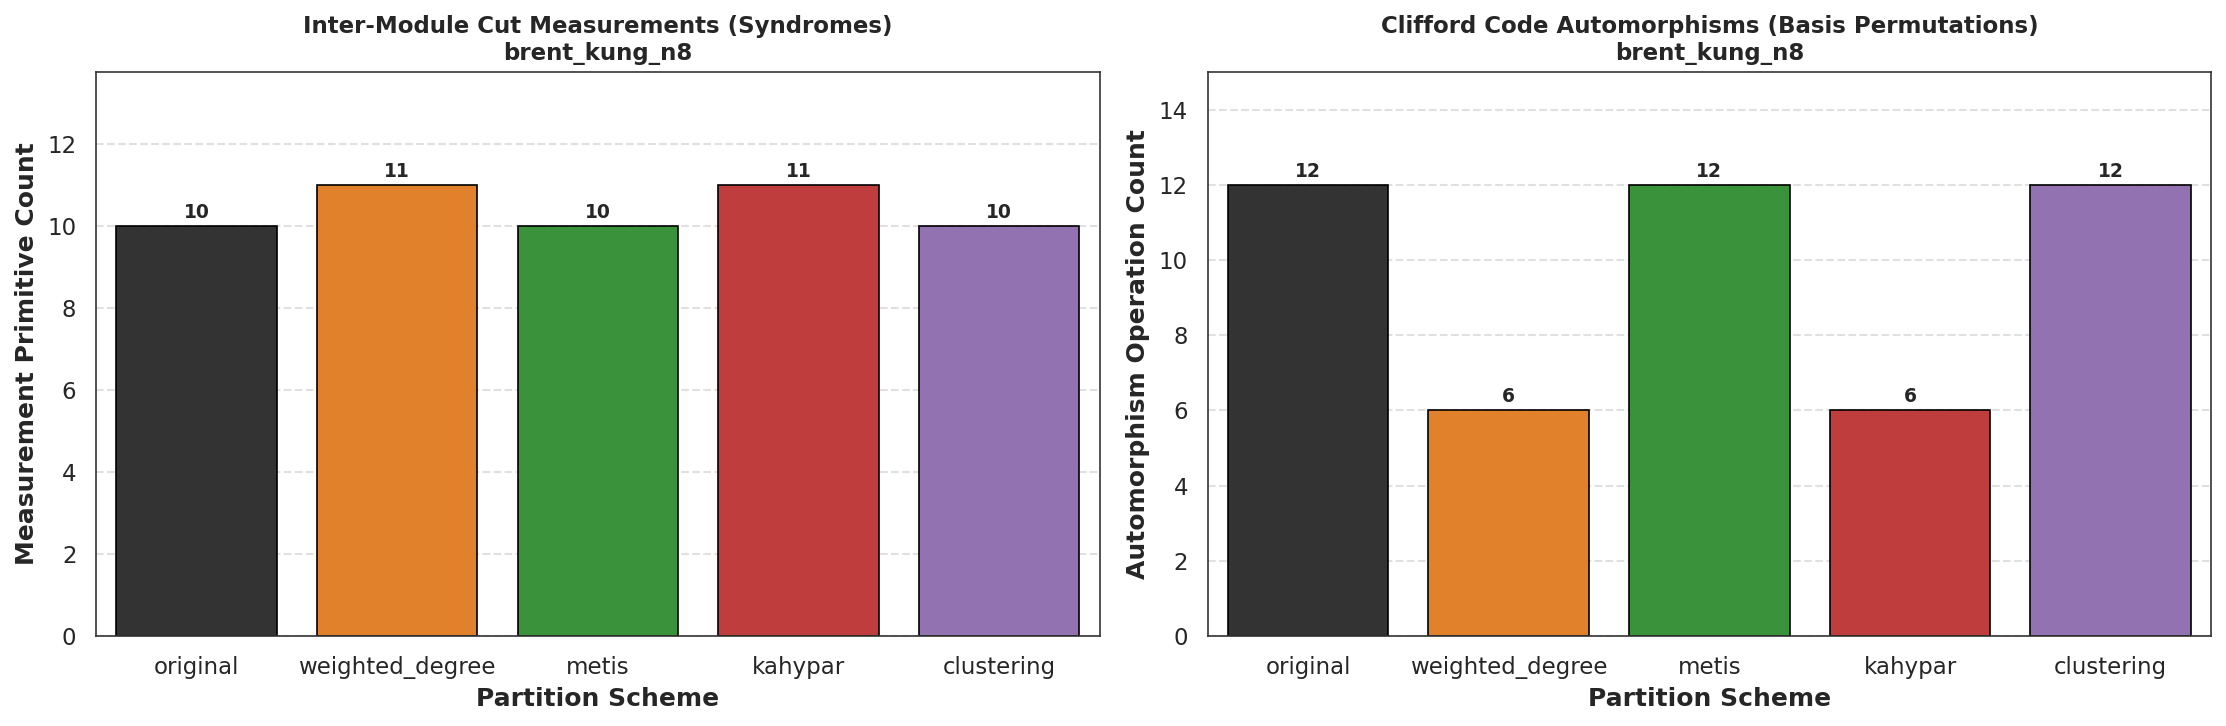

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Inter-Module Syndrome Measurements
sns.barplot(
    data=df_eval,
    x="partition",
    y="measurements",
    order=active_schemes,
    palette=color_palette,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[0]
)

for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        axes[0].annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold",
            xytext=(0, 2), textcoords="offset points"
        )

axes[0].set_title(f"Inter-Module Cut Measurements (Syndromes)\n{target_tag}", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Measurement Primitive Count", fontweight="bold")
axes[0].set_xlabel("Partition Scheme", fontweight="bold")
axes[0].set_ylim(0, df_eval["measurements"].max() * 1.25)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# 2. Clifford Code Automorphisms
sns.barplot(
    data=df_eval,
    x="partition",
    y="automorphisms",
    order=active_schemes,
    palette=color_palette,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[1]
)

for p in axes[1].patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        axes[1].annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold",
            xytext=(0, 2), textcoords="offset points"
        )

axes[1].set_title(f"Clifford Code Automorphisms (Basis Permutations)\n{target_tag}", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Automorphism Operation Count", fontweight="bold")
axes[1].set_xlabel("Partition Scheme", fontweight="bold")
axes[1].set_ylim(0, df_eval["automorphisms"].max() * 1.25)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_97252/4070657235.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_97252/4070657235.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_97252/4070657235.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


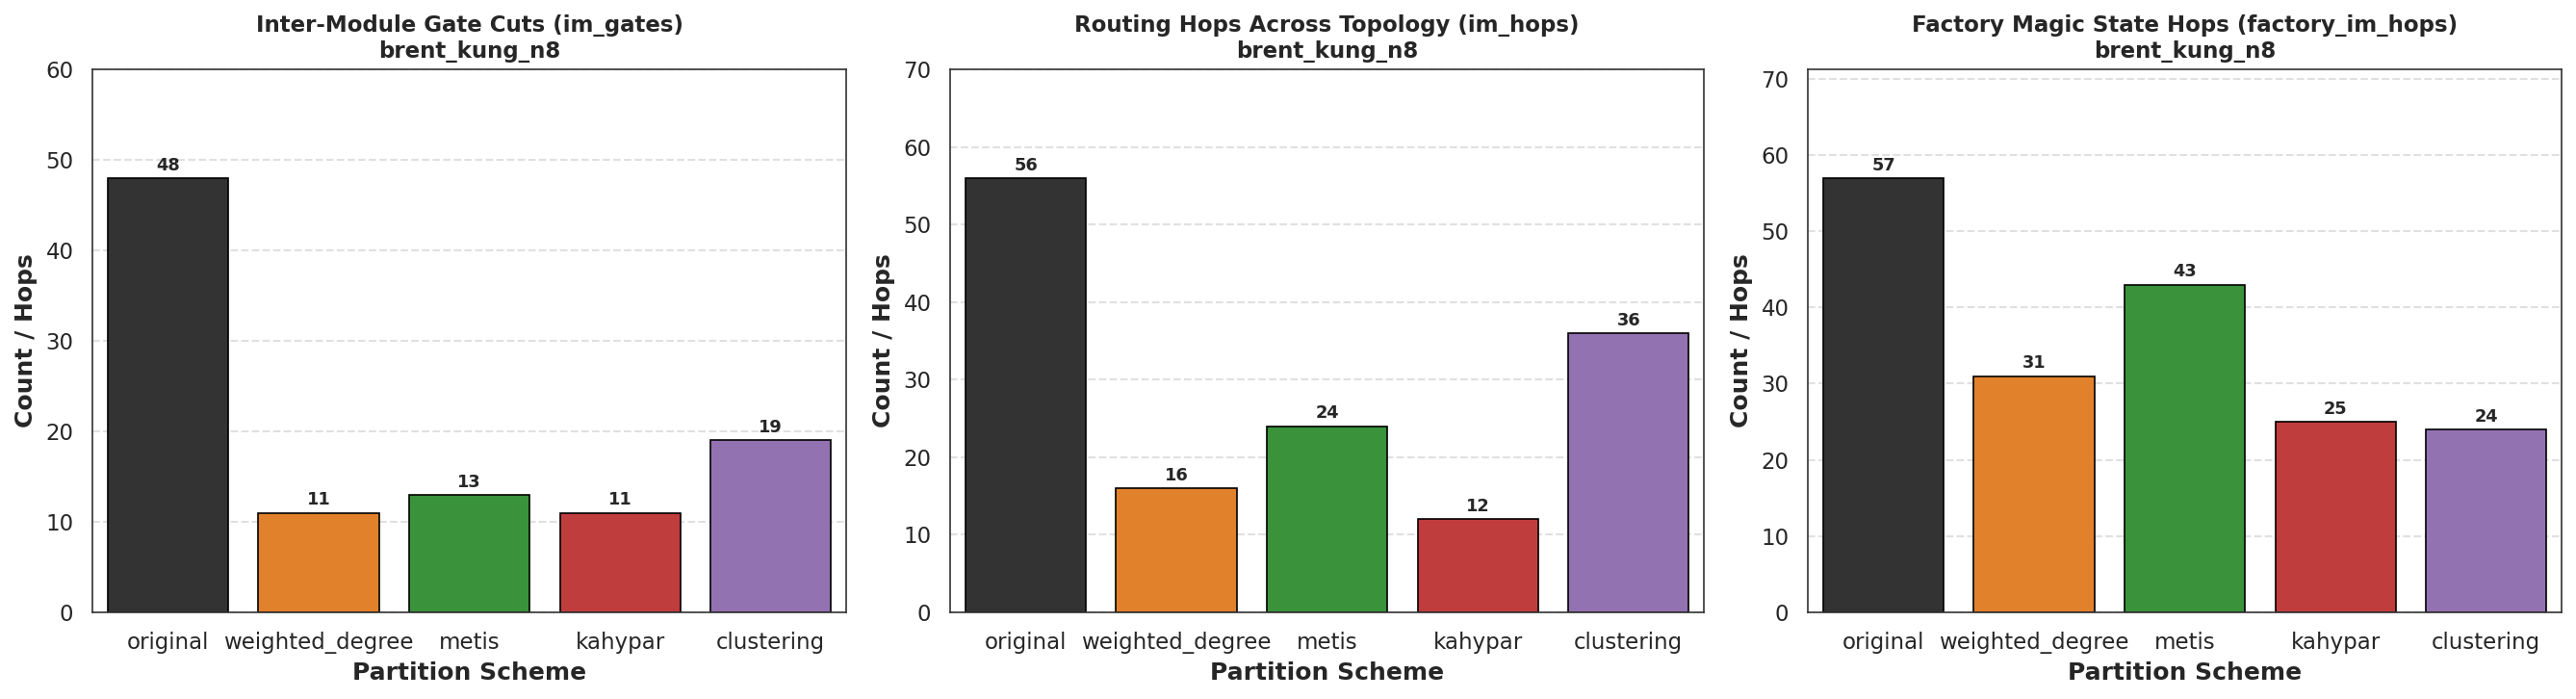

In [14]:
im_cols_present = [c for c in ["im_gates", "im_hops", "factory_im_hops"] if c in df_eval.columns]

if not im_cols_present:
    print(f"Skipping IM Traffic Plot: Columns 'im_gates', 'im_hops', or 'factory_im_hops' not present in dataset.")
else:
    num_im_plots = len(im_cols_present)
    fig, axes = plt.subplots(1, num_im_plots, figsize=(6 * num_im_plots, 5))
    if num_im_plots == 1:
        axes = [axes]

    titles = {
        "im_gates": "Inter-Module Gate Cuts (im_gates)",
        "im_hops": "Routing Hops Across Topology (im_hops)",
        "factory_im_hops": "Factory Magic State Hops (factory_im_hops)"
    }

    for idx, col_name in enumerate(im_cols_present):
        ax = axes[idx]
        sns.barplot(
            data=df_eval,
            x="partition",
            y=col_name,
            order=active_schemes,
            palette=color_palette,
            edgecolor="black",
            linewidth=0.8,
            ax=ax
        )

        for p in ax.patches:
            h = p.get_height()
            if not np.isnan(h) and h > 0:
                ax.annotate(
                    f"{int(h)}",
                    (p.get_x() + p.get_width() / 2.0, h),
                    ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold",
                    xytext=(0, 2), textcoords="offset points"
                )

        ax.set_title(f"{titles.get(col_name, col_name)}\n{target_tag}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Count / Hops", fontweight="bold")
        ax.set_xlabel("Partition Scheme", fontweight="bold")
        ax.set_ylim(0, df_eval[col_name].max() * 1.25)
        ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_97252/820810681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


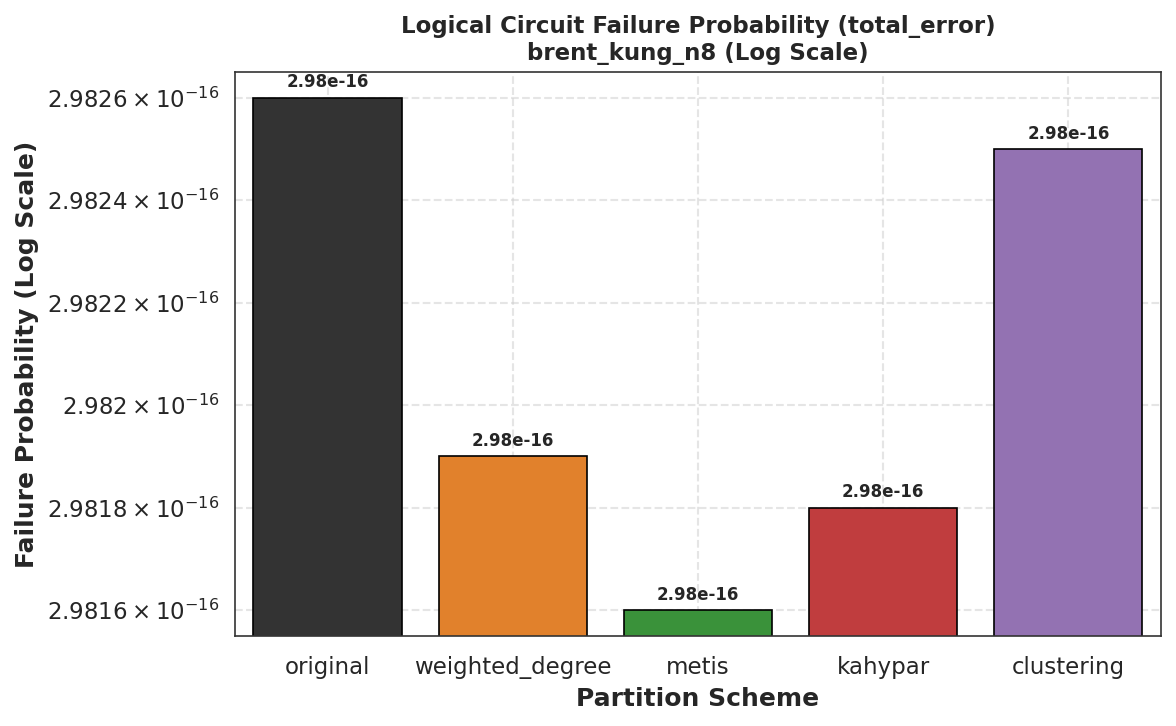

In [15]:
error_col = "failure_prob" if "failure_prob" in df_eval.columns else ("total_error" if "total_error" in df_eval.columns else None)

if error_col is None:
    print("Skipping Error Rate Plot: Neither 'failure_prob' nor 'total_error' found.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=df_eval,
        x="partition",
        y=error_col,
        order=active_schemes,
        palette=color_palette,
        edgecolor="black",
        linewidth=0.8,
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_title(f"Logical Circuit Failure Probability ({error_col})\n{target_tag} (Log Scale)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Failure Probability (Log Scale)", fontweight="bold")
    ax.set_xlabel("Partition Scheme", fontweight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{h:.2e}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center", va="bottom",
                fontsize=8, fontweight="bold",
                xytext=(0, 3), textcoords="offset points"
            )

    plt.tight_layout()
    plt.show()

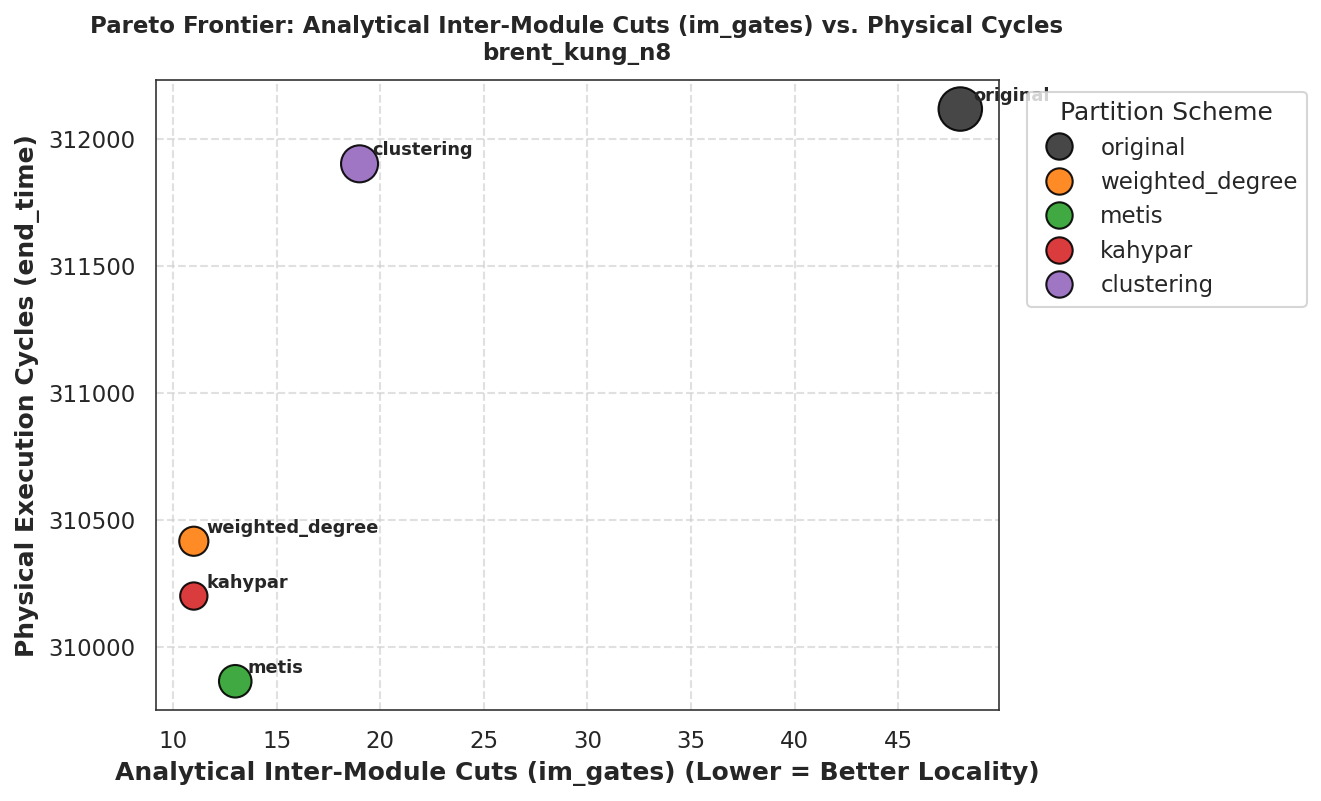

In [17]:
# Cell 8: Pareto Trade-Off (Cuts vs. Physical Runtime Cycles)

x_axis_candidate = "im_gates" if "im_gates" in df_eval.columns else "measurement_depth"
x_label_text = "Analytical Inter-Module Cuts (im_gates)" if x_axis_candidate == "im_gates" else "Measurement Depth"

fig, ax = plt.subplots(figsize=(9, 5.5))

# Identify column for dynamic bubble scaling
size_col = "total_im_hops" if "total_im_hops" in df_eval.columns else ("im_hops" if "im_hops" in df_eval.columns else None)

# 1. Plot with scalar s=160 so the legend proxy receives a valid float
sns.scatterplot(
    data=df_eval,
    x=x_axis_candidate,
    y="end_time",
    hue="partition",
    hue_order=active_schemes,
    palette=color_palette,
    s=160,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9,
    ax=ax
)

# 2. Dynamically scale the rendered canvas bubbles
if size_col and size_col in df_eval.columns and len(ax.collections) > 0:
    bubble_sizes = (df_eval[size_col].to_numpy() * 6 + 100)
    ax.collections[0].set_sizes(bubble_sizes)

# 3. Label each partition scheme
for _, r in df_eval.iterrows():
    ax.annotate(
        r["partition"],
        (r[x_axis_candidate], r["end_time"]),
        fontsize=8.5,
        fontweight="bold",
        xytext=(6, 4),
        textcoords="offset points"
    )

ax.set_title(f"Pareto Frontier: {x_label_text} vs. Physical Cycles\n{target_tag}", fontsize=11, fontweight="bold", pad=10)
ax.set_xlabel(f"{x_label_text} (Lower = Better Locality)", fontweight="bold")
ax.set_ylabel("Physical Execution Cycles (end_time)", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Partition Scheme", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

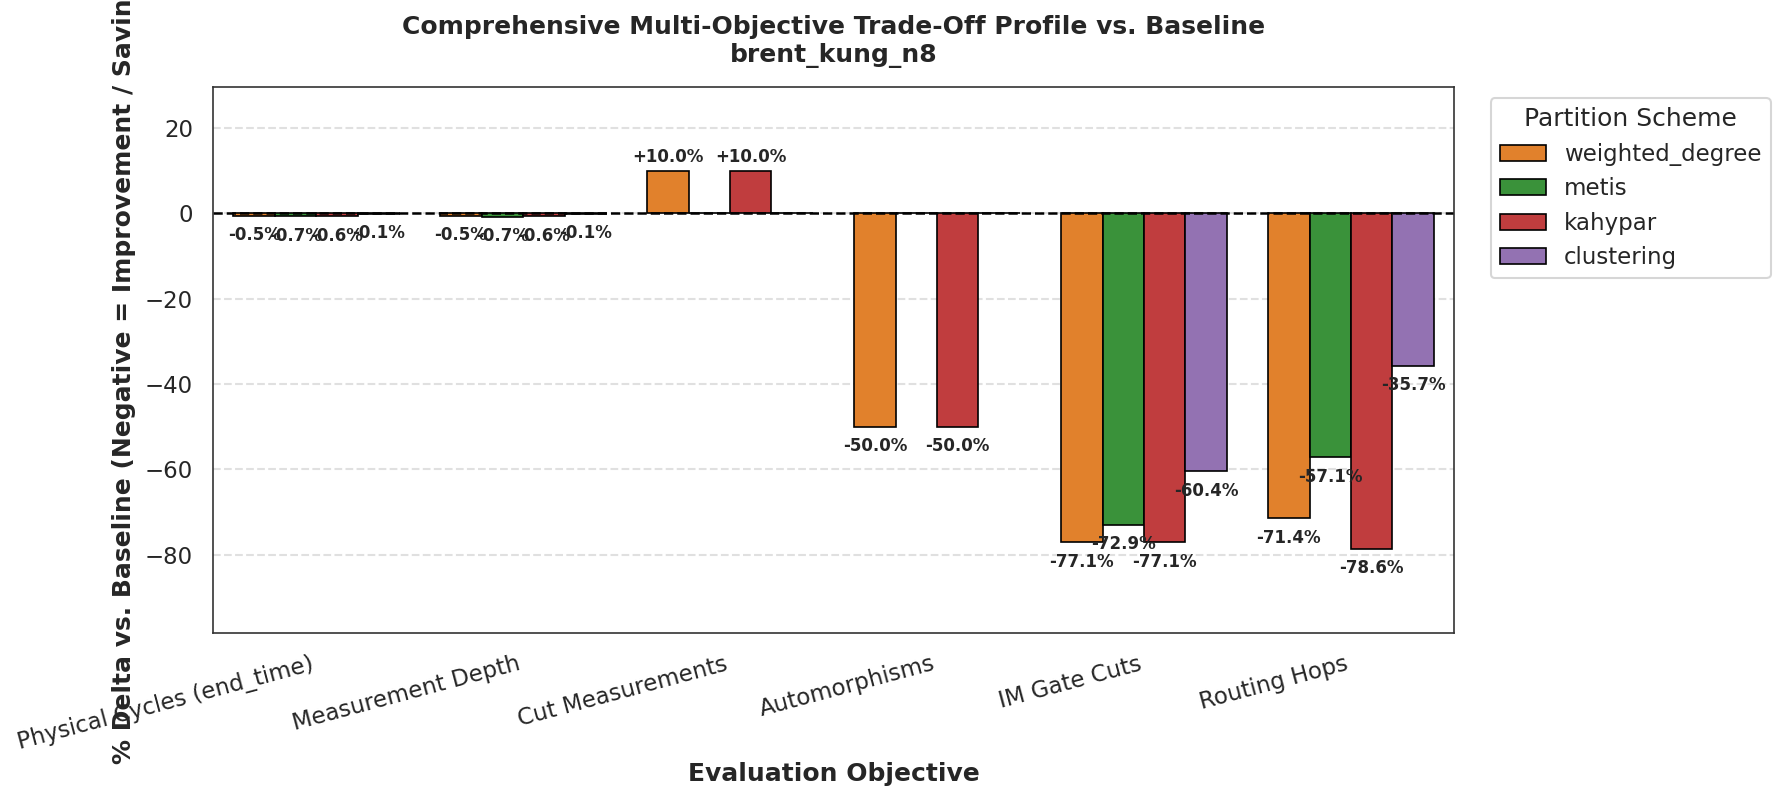

In [18]:
# Cell 9: Comprehensive Multi-Objective Trade-Off Profile vs. Original Baseline

tradeoff_specs = [
    ("time_pct", "Physical Cycles (end_time)"),
    ("depth_pct", "Measurement Depth"),
    ("measurements_pct", "Cut Measurements"),
    ("automorphisms_pct", "Automorphisms"),
    ("im_gates_pct", "IM Gate Cuts"),
    ("im_hops_pct", "Routing Hops"),
]

non_baseline = df_eval[df_eval["partition"] != "original"].copy()
non_base_schemes = [s for s in active_schemes if s != "original"]

# Reshape into long-form dataframe
profile_records = []
for _, r in non_baseline.iterrows():
    scheme = r["partition"]
    for col_key, label_name in tradeoff_specs:
        if col_key in r and pd.notna(r[col_key]):
            profile_records.append({
                "partition": scheme,
                "metric": label_name,
                "pct_delta": float(r[col_key])
            })

df_profile = pd.DataFrame(profile_records)

fig, ax = plt.subplots(figsize=(12, 5.5))

sns.barplot(
    data=df_profile,
    x="metric",
    y="pct_delta",
    hue="partition",
    hue_order=non_base_schemes,
    palette=color_palette,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.2)

# Annotate exact percentage deltas over each bar
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and abs(h) > 0.01:
        va = "bottom" if h >= 0 else "top"
        y_offset = 1.0 if h >= 0 else -2.5
        ax.annotate(
            f"{h:+.1f}%",
            (p.get_x() + p.get_width() / 2.0, h + y_offset),
            ha="center", va=va,
            fontsize=8, fontweight="bold"
        )

ax.set_title(f"Comprehensive Multi-Objective Trade-Off Profile vs. Baseline\n{target_tag}", fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("% Delta vs. Baseline (Negative = Improvement / Savings)", fontweight="bold")
ax.set_xlabel("Evaluation Objective", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(title="Partition Scheme", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15, ha="right")

# Dynamic headroom padding
y_min = df_profile["pct_delta"].min() if not df_profile.empty else -10
y_max = df_profile["pct_delta"].max() if not df_profile.empty else 10
padding = max(abs(y_min), abs(y_max), 10) * 0.25
ax.set_ylim(min(y_min - padding, -5), max(y_max + padding, 5))

plt.tight_layout()
plt.show()

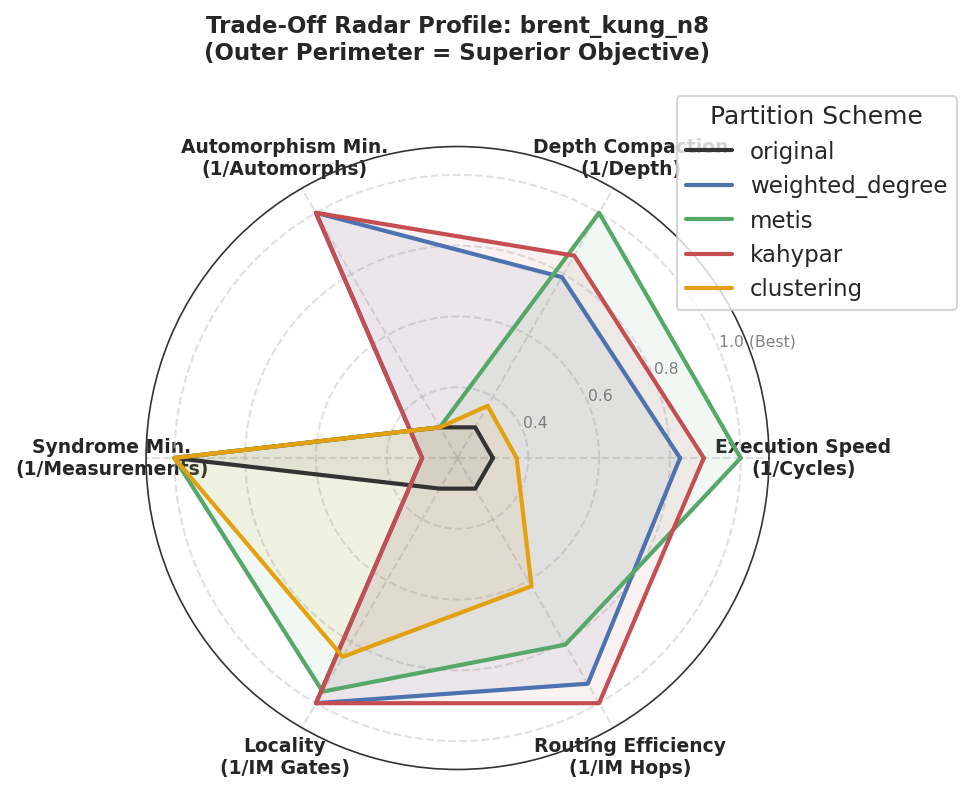

In [19]:
# =====================================================================
# Cell: Multi-Dimensional Trade-Off Radar Profile (Spider Chart)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Identify Target Data (uses df_eval if already filtered, or searches df_analysis/master_df)
SELECTED_ADDER = (
    target_tag
    if "target_tag" in locals()
    else ("df_eval" in locals() and df_eval["adder"].iloc[0] or "sklansky_n8")
)

if "df_eval" in locals() and not df_eval.empty:
  sub_df = df_eval.copy()
elif "df_analysis" in locals():
  sub_df = df_analysis[df_analysis["adder"] == SELECTED_ADDER].copy()
  if sub_df.empty:
    sub_df = df_analysis[
        df_analysis["adder"].str.contains("kogge_stone")
    ].copy()
else:
  sub_df = df_target.copy()

# 2. Define Objectives (All hardware costs where lower is better)
candidate_metrics = [
    ("end_time", "Execution Speed\n(1/Cycles)"),
    ("measurement_depth", "Depth Compaction\n(1/Depth)"),
    ("automorphisms", "Automorphism Min.\n(1/Automorphs)"),
    ("measurements", "Syndrome Min.\n(1/Measurements)"),
    ("im_gates", "Locality\n(1/IM Gates)"),
    ("im_hops", "Routing Efficiency\n(1/IM Hops)"),
]

# Keep only metrics actually present in the dataset
active_metric_pairs = [
    pair for pair in candidate_metrics if pair[0] in sub_df.columns
]
metrics_keys = [pair[0] for pair in active_metric_pairs]
categories = [pair[1] for pair in active_metric_pairs]
N = len(categories)

# 3. Invert metrics so lower hardware cost yields higher score (0.3 inner to 1.0 outer perimeter)
scores = {}
for k in metrics_keys:
  vals = pd.to_numeric(sub_df[k], errors="coerce").dropna().values
  min_v, max_v = vals.min(), vals.max()
  if max_v == min_v:
    scores[k] = {p: 1.0 for p in sub_df["partition"]}
  else:
    scores[k] = {
        p: (
            1.0
            - 0.7
            * (
                float(sub_df[sub_df["partition"] == p][k].values[0]) - min_v
            )
            / (max_v - min_v)
        )
        for p in sub_df["partition"]
    }

# 4. Compute Radar Angles (closing the loop with angles[:1])
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 5. Render Polar Chart
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

palette = {
    "original": "#333333",
    "weighted_degree": "#4C72B0",
    "metis": "#55A868",
    "kahypar": "#C44E52",
    "clustering": "#E4A10F",
}
schemes_to_plot = [
    p
    for p in ["original", "weighted_degree", "metis", "kahypar", "clustering"]
    if p in sub_df["partition"].values
]

for p in schemes_to_plot:
  vals = [scores[k][p] for k in metrics_keys]
  vals += vals[:1]
  c = palette.get(p, "#888888")
  ax.plot(angles, vals, linewidth=2.0, label=p, color=c)
  ax.fill(angles, vals, color=c, alpha=0.08)

# 6. Formatting & Polar Gridlines
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9, fontweight="bold")
ax.set_ylim(0.2, 1.08)
ax.set_yticks([0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ["0.4", "0.6", "0.8", "1.0 (Best)"], fontsize=7.5, color="grey"
)
ax.grid(True, linestyle="--", alpha=0.6)

adder_title = sub_df["adder"].iloc[0] if "adder" in sub_df.columns else target_tag
ax.set_title(
    f"Trade-Off Radar Profile: {adder_title}\n(Outer Perimeter = Superior"
    " Objective)",
    fontweight="bold",
    fontsize=11,
    y=1.12,
)
ax.legend(
    title="Partition Scheme",
    loc="upper right",
    bbox_to_anchor=(1.32, 1.1),
    frameon=True,
)

plt.tight_layout()
plt.show()